# Beyond Accuracy: Building a Comprehensive Recommender System Evaluator

**Author**: Elias Abou Haydar

This notebook demonstrates the step-by-step thinking process behind building a comprehensive evaluation framework for recommender systems. We'll build our evaluator step by step, explaining **WHY** we make each design decision and **HOW** each component fits together.

What will be covering :
1. What questions are we trying to answer?
2. How do we categorize different types of evaluation?
3. What does each metric family tell us?
4. How do we structure code for extensibility?
5. How do we handle real-world complexities?
6. How do we make it all work together?

In [1]:
import numpy as np
import pandas as pd
from typing import Dict, List, Tuple, Optional, Union
from scipy.sparse import csr_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import dataclass
import warnings

warnings.filterwarnings('ignore')

## Step 1: What Questions Are We Trying To Answer?
🤔 Before writing any code, let's think about what questions we're trying to answer:

📊 TECHNICAL QUESTIONS:
- How accurate are our predictions? → Accuracy Metrics (RMSE, MAE)
- How good is our ranking? → Ranking Metrics (NDCG, MAP)
- How relevant are our recommendations? → Classification Metrics (Precision, Recall)

🎯 USER EXPERIENCE QUESTIONS:
- Are we helping users discover new items? → Diversity & Novelty
- Are we covering our catalog well? → Coverage Metrics
- Are recommendations surprising but relevant? → Serendipity

💼 BUSINESS QUESTIONS:
- Are users clicking on recommendations? → Click-Through Rate
- Are they buying recommended items? → Conversion Rate
- Are we keeping users engaged long-term? → Retention Metrics

🔧 SYSTEM QUESTIONS:
- Can we handle the scale? → Performance Metrics
- Are we being fair to all users? → Fairness Metrics

In [2]:
# Let's design our evaluation config to reflect these concerns
@dataclass
class EvaluationConfig:
    """
    THOUGHT: We need a configuration system that's flexible but has sensible defaults.
    This helps users get started quickly while allowing customization for specific needs.
    """
    # Core parameters
    k: int = 10  # Top-k for ranking metrics
    rating_threshold: float = 3.5  # What counts as "relevant"
    random_state: int = 42  # Reproducibility
    
    # Data filtering (important for noisy real-world data)
    min_interactions: int = 5  # Filter out sparse users/items
    
    def __post_init__(self):
        """Validate configuration parameters"""
        if self.k <= 0:
            raise ValueError("k must be positive")
        if not 1 <= self.rating_threshold <= 5:
            raise ValueError("rating_threshold should be between 1 and 5")
        print(f"✅ Evaluation configured: k={self.k}, threshold={self.rating_threshold}")

# Test our config
config = EvaluationConfig(k=10, rating_threshold=3.5)

✅ Evaluation configured: k=10, threshold=3.5


## Step 2: How Do We Categorize Evaluation Metrics?

DESIGN DECISION: We'll create separate classes for each metric family.
WHY? This makes the code:
- Easier to understand and maintain
- Modular (can use parts independently) 
- Extensible (easy to add new metrics)
- Testable (can test each family separately)

Let's build each family step by step...

### METRIC FAMILY 1: ACCURACY METRICS

THOUGHT PROCESS:
- These are the most basic metrics - how close are our predictions?
- RMSE vs MAE: RMSE penalizes large errors more heavily
- MAPE: Useful for understanding percentage errors
- We need to handle edge cases (division by zero, etc.)

In [3]:
class AccuracyMetrics:    
    @staticmethod
    def rmse(true_ratings: np.ndarray, predicted_ratings: np.ndarray) -> float:
        """
        Root Mean Square Error - emphasizes larger errors
        THOUGHT: Perfect for when occasional large errors are particularly bad
        """
        if len(true_ratings) == 0:
            return 0.0
        return np.sqrt(np.mean((true_ratings - predicted_ratings) ** 2))
    
    @staticmethod
    def mae(true_ratings: np.ndarray, predicted_ratings: np.ndarray) -> float:
        """
        Mean Absolute Error - treats all errors equally
        THOUGHT: Better for understanding typical error magnitude
        """
        if len(true_ratings) == 0:
            return 0.0
        return np.mean(np.abs(true_ratings - predicted_ratings))
    
    @staticmethod
    def mape(true_ratings: np.ndarray, predicted_ratings: np.ndarray) -> float:
        """
        Mean Absolute Percentage Error
        THOUGHT: Useful for relative error understanding, but watch out for zero values
        """
        mask = true_ratings != 0
        if not np.any(mask):
            return float('inf')
        return np.mean(np.abs((true_ratings[mask] - predicted_ratings[mask]) / true_ratings[mask])) * 100
    
    def calculate_all(self, true_ratings: np.ndarray, predicted_ratings: np.ndarray) -> Dict[str, float]:
        """
        THOUGHT: Convenience method to get all metrics at once
        Returns a dictionary for easy integration with other systems
        """
        return {
            'rmse': self.rmse(true_ratings, predicted_ratings),
            'mae': self.mae(true_ratings, predicted_ratings),
            'mape': self.mape(true_ratings, predicted_ratings)
        }

In [4]:
# Test the accuracy metrics
print("🧪 Testing Accuracy Metrics:")
true_vals = np.array([4.0, 3.5, 5.0, 2.0, 4.5])
pred_vals = np.array([3.8, 3.7, 4.8, 2.2, 4.3])

accuracy_calc = AccuracyMetrics()
accuracy_results = accuracy_calc.calculate_all(true_vals, pred_vals)

print(f"Results: {accuracy_results}")
print("✅ Accuracy metrics working!")

🧪 Testing Accuracy Metrics:
Results: {'rmse': 0.20000000000000018, 'mae': 0.20000000000000018, 'mape': 5.831746031746037}
✅ Accuracy metrics working!


### METRIC FAMILY 2: RANKING METRICS

THOUGHT PROCESS FOR RANKING METRICS:
- In practice, we show users ranked lists, not raw ratings
- Position matters: item at rank 1 is more important than rank 10
- We need metrics that understand both relevance AND position
- NDCG is gold standard but complex; MRR and MAP are simpler alternatives

In [5]:
class RankingMetrics:
    """
    THOUGHT: These metrics evaluate how good our ranking is
    Key insight: Perfect rating prediction ≠ Perfect ranking
    """
    
    def __init__(self, k: int = 10):
        self.k = k
        print(f"🏆 Ranking metrics initialized with k={k}")
    
    def dcg_at_k(self, relevance_scores: np.ndarray, k: Optional[int] = None) -> float:
        """
        Discounted Cumulative Gain
        THOUGHT: This is the building block for NDCG
        The discounting (log2) makes top positions more important
        """
        if k is None:
            k = self.k
        
        relevance_scores = relevance_scores[:k]
        if len(relevance_scores) == 0:
            return 0.0
        
        # The magic formula: gains are discounted by position
        gains = 2 ** relevance_scores - 1  # Convert relevance to gain
        discounts = np.log2(np.arange(len(relevance_scores)) + 2)  # Position discount
        return np.sum(gains / discounts)
    
    def ndcg_at_k(self, true_relevance: np.ndarray, predicted_scores: np.ndarray, k: Optional[int] = None) -> float:
        """
        Normalized DCG - the gold standard for ranking evaluation
        THOUGHT: Normalizing by ideal DCG makes scores comparable across users
        """
        if k is None:
            k = self.k
        
        # Get our system's ranking
        sorted_indices = np.argsort(-predicted_scores)[:k]
        relevance_at_k = true_relevance[sorted_indices]
        
        # Calculate actual DCG
        dcg = self.dcg_at_k(relevance_at_k, k)
        
        # Calculate ideal DCG (best possible ranking)
        ideal_relevance = np.sort(true_relevance)[::-1][:k]
        idcg = self.dcg_at_k(ideal_relevance, k)
        
        return dcg / idcg if idcg > 0 else 0.0
    
    def mrr(self, true_relevance: np.ndarray, predicted_scores: np.ndarray) -> float:
        """
        Mean Reciprocal Rank - focuses on first relevant item
        THOUGHT: Simple but effective when you only care about the first good recommendation
        """
        sorted_indices = np.argsort(-predicted_scores)
        
        for i, idx in enumerate(sorted_indices):
            if true_relevance[idx] > 0:  # First relevant item found
                return 1.0 / (i + 1)
        return 0.0
    
    def map_at_k(self, true_relevance: np.ndarray, predicted_scores: np.ndarray, k: Optional[int] = None) -> float:
        """
        Mean Average Precision
        THOUGHT: Balances precision across all relevant items in top-k
        """
        if k is None:
            k = self.k
        
        sorted_indices = np.argsort(-predicted_scores)[:k]
        relevance_at_k = true_relevance[sorted_indices]
        
        if np.sum(relevance_at_k) == 0:
            return 0.0
        
        precisions = []
        relevant_count = 0
        
        for i, rel in enumerate(relevance_at_k):
            if rel > 0:
                relevant_count += 1
                precision = relevant_count / (i + 1)
                precisions.append(precision)
        
        return np.mean(precisions) if precisions else 0.0
    
    def calculate_all(self, true_relevance: np.ndarray, predicted_scores: np.ndarray) -> Dict[str, float]:
        """Calculate all ranking metrics"""
        return {
            'ndcg': self.ndcg_at_k(true_relevance, predicted_scores),
            'mrr': self.mrr(true_relevance, predicted_scores),
            'map': self.map_at_k(true_relevance, predicted_scores)
        }

In [6]:
# Test ranking metrics
print("🧪 Testing Ranking Metrics:")
true_rel = np.array([3, 1, 2, 0, 1])  # Relevance scores
pred_scores = np.array([0.9, 0.8, 0.7, 0.6, 0.5])  # Our predictions

ranking_calc = RankingMetrics(k=5)
ranking_results = ranking_calc.calculate_all(true_rel, pred_scores)
print(f"Results: {ranking_results}")
print("✅ Ranking metrics working!")

🧪 Testing Ranking Metrics:
🏆 Ranking metrics initialized with k=5
Results: {'ndcg': 0.9688823411593558, 'mrr': 1.0, 'map': 0.95}
✅ Ranking metrics working!


### METRIC FAMILY 3: CLASSIFICATION METRICS

THOUGHT PROCESS FOR CLASSIFICATION METRICS:
- Sometimes we want to think in binary terms: relevant vs not relevant
- Precision: Of what we recommended, how much was good?
- Recall: Of all good items, how much did we find?
- This bridges the gap between rating prediction and ranking

In [7]:
class ClassificationMetrics:
    """
    THOUGHT: Convert the rating problem to a classification problem
    This gives us familiar ML metrics like precision and recall
    """
    
    def __init__(self, threshold: float = 3.5, k: int = 10):
        self.threshold = threshold
        self.k = k
        print(f"✅ Classification metrics initialized with threshold={threshold}, k={k}")
    
    def precision_at_k(self, true_ratings: np.ndarray, predicted_scores: np.ndarray, k: Optional[int] = None) -> float:
        """
        Precision@k: What fraction of recommended items are relevant?
        THOUGHT: This answers "If I follow your top-k recommendations, how many will I like?"
        """
        if k is None:
            k = self.k
        
        # Get top-k recommendations
        top_k_indices = np.argsort(-predicted_scores)[:k]
        
        # Count how many are actually relevant (above threshold)
        relevant_in_topk = np.sum(true_ratings[top_k_indices] >= self.threshold)
        
        return relevant_in_topk / k if k > 0 else 0.0
    
    def recall_at_k(self, true_ratings: np.ndarray, predicted_scores: np.ndarray, k: Optional[int] = None) -> float:
        """
        Recall@k: What fraction of relevant items did we recommend?
        THOUGHT: This answers "Of all items I would like, how many did you find?"
        """
        if k is None:
            k = self.k
        
        # How many items are actually relevant?
        total_relevant = np.sum(true_ratings >= self.threshold)
        if total_relevant == 0:
            return 0.0
        
        # How many relevant items did we get in top-k?
        top_k_indices = np.argsort(-predicted_scores)[:k]
        relevant_in_topk = np.sum(true_ratings[top_k_indices] >= self.threshold)
        
        return relevant_in_topk / total_relevant
    
    def f1_at_k(self, true_ratings: np.ndarray, predicted_scores: np.ndarray, k: Optional[int] = None) -> float:
        """
        F1@k: Harmonic mean of precision and recall
        THOUGHT: Balances both precision and recall - good overall metric
        """
        precision = self.precision_at_k(true_ratings, predicted_scores, k)
        recall = self.recall_at_k(true_ratings, predicted_scores, k)
        
        if precision + recall == 0:
            return 0.0
        return 2 * (precision * recall) / (precision + recall)
    
    def calculate_all(self, true_ratings: np.ndarray, predicted_scores: np.ndarray) -> Dict[str, float]:
        """Calculate all classification metrics"""
        return {
            'precision': self.precision_at_k(true_ratings, predicted_scores),
            'recall': self.recall_at_k(true_ratings, predicted_scores),
            'f1_score': self.f1_at_k(true_ratings, predicted_scores)
        }

In [8]:
# Test classification metrics
print("🧪 Testing Classification Metrics:")
true_ratings = np.array([4.5, 2.0, 3.8, 1.5, 4.2])  # Some above/below threshold
pred_scores = np.array([0.9, 0.2, 0.8, 0.1, 0.85])  # Our predictions

classification_calc = ClassificationMetrics(threshold=3.5, k=3)
classification_results = classification_calc.calculate_all(true_ratings, pred_scores)
print(f"Results: {classification_results}")
print("✅ Classification metrics working!")

🧪 Testing Classification Metrics:
✅ Classification metrics initialized with threshold=3.5, k=3
Results: {'precision': 1.0, 'recall': 1.0, 'f1_score': 1.0}
✅ Classification metrics working!


## Step 3: Why Do We Need "BEYOND-ACCURACY" Metrics?

CRITICAL INSIGHT: Accuracy metrics can be misleading!

Example: A system that always recommends the most popular items might have:
- ✅ High accuracy (popular items are often well-liked)
- ✅ Good precision (people do like popular items)
- ❌ Zero novelty (no discovery)
- ❌ Poor coverage (ignores long-tail)
- ❌ Bad business impact (no differentiation from competitors)

This is why we need metrics that capture:
- Diversity: Are we showing variety?
- Coverage: Are we using our full catalog?
- Novelty: Are we helping users discover?
- Serendipity: Are we surprising users pleasantly?

### METRIC FAMILY 4: BEYOND-ACCURACY METRICS

In [9]:
class DiversityMetrics:
    """
    THOUGHT PROCESS:
    - These metrics capture what accuracy metrics miss
    - Diversity = showing variety within recommendations
    - Coverage = utilizing the full item catalog
    - Novelty = recommending unpopular (but good) items
    - These often trade off with accuracy but improve long-term satisfaction
    """
    
    def __init__(self, k: int = 10):
        self.k = k
        print(f"🌈 Diversity metrics initialized with k={k}")
    
    def item_coverage(self, all_recommendations: List[List[int]], total_items: int) -> float:
        """
        What fraction of all items do we ever recommend?
        THOUGHT: Low coverage means we're ignoring parts of our catalog
        This can be bad for business (unsold inventory) and users (limited discovery)
        """
        unique_items = set()
        for user_recs in all_recommendations:
            unique_items.update(user_recs)
        
        coverage = len(unique_items) / total_items if total_items > 0 else 0.0
        print(f"📊 Item coverage: {coverage:.3f} ({len(unique_items)} out of {total_items} items)")
        return coverage
    
    def user_coverage(self, all_recommendations: List[List[int]], total_users: int) -> float:
        """
        What fraction of users get any recommendations?
        THOUGHT: Important for systems with cold-start problems
        """
        users_with_recs = sum(1 for recs in all_recommendations if len(recs) > 0)
        return users_with_recs / total_users if total_users > 0 else 0.0
    
    def intra_list_diversity(self, recommendations: List[int], item_features: np.ndarray) -> float:
        """
        How diverse are the items within a single recommendation list?
        THOUGHT: We calculate pairwise distances between items in the list
        Higher distance = more diverse recommendations
        """
        if len(recommendations) <= 1:
            return 0.0
        
        total_distance = 0.0
        count = 0
        
        # Calculate all pairwise distances
        for i in range(len(recommendations)):
            for j in range(i + 1, len(recommendations)):
                item1_features = item_features[recommendations[i]]
                item2_features = item_features[recommendations[j]]
                
                # Use cosine distance (1 - cosine similarity)
                dot_product = np.dot(item1_features, item2_features)
                norm1 = np.linalg.norm(item1_features)
                norm2 = np.linalg.norm(item2_features)
                
                if norm1 > 0 and norm2 > 0:
                    cosine_sim = dot_product / (norm1 * norm2)
                    distance = 1 - cosine_sim
                    total_distance += distance
                    count += 1
        
        return total_distance / count if count > 0 else 0.0
    
    def novelty_score(self, recommendations: List[int], item_popularity: np.ndarray) -> float:
        """
        How novel (unpopular) are our recommendations?
        THOUGHT: Novelty is inverse of popularity
        Recommending unpopular items that users like = good discovery
        """
        if len(recommendations) == 0:
            return 0.0
        
        # Get popularity scores for recommended items
        popularities = item_popularity[recommendations]
        
        # Novelty is inverse of popularity (add epsilon to avoid division by zero)
        novelties = 1.0 / (popularities + 1e-8)
        
        return np.mean(novelties)
    
    def calculate_all(self, all_recommendations: List[List[int]], item_features: np.ndarray,
                      item_popularity: np.ndarray, total_items: int) -> Dict[str, float]:
        """Calculate all diversity metrics"""
        # Coverage metrics
        item_cov = self.item_coverage(all_recommendations, total_items)
        user_cov = self.user_coverage(all_recommendations, len(all_recommendations))
        
        # Average diversity and novelty across all users
        diversities = []
        novelties = []
        
        for recs in all_recommendations:
            if len(recs) > 0:
                if len(recs) > 1:  # Need at least 2 items for diversity
                    div = self.intra_list_diversity(recs, item_features)
                    diversities.append(div)
                
                nov = self.novelty_score(recs, item_popularity)
                novelties.append(nov)
        
        return {
            'item_coverage': item_cov,
            'user_coverage': user_cov,
            'avg_diversity': np.mean(diversities) if diversities else 0.0,
            'avg_novelty': np.mean(novelties) if novelties else 0.0
        }

## Step 4: How Do We Handle Business Metrics ?

BUSINESS REALITY CHECK:
At the end of the day, recommender systems need to drive business value.

The best technical metrics mean nothing if:
- ❌ Users don't click on recommendations (CTR)
- ❌ They don't buy recommended items (Conversion Rate) 
- ❌ They don't come back (Retention)
- ❌ Revenue doesn't increase

These metrics bridge the gap between technical performance and business impact.


In [10]:
class BusinessMetrics:
    """
    THOUGHT: These metrics answer the question "Is this system actually valuable?"
    They're harder to optimize directly but ultimately most important
    """
    
    def click_through_rate(self, recommendations: List[List[int]], actual_interactions: List[List[int]]) -> float:
        """
        What fraction of recommendations do users actually click?
        THOUGHT: This is immediate feedback - are recommendations engaging?
        """
        total_recommendations = 0
        clicked_recommendations = 0
        
        for user_recs, user_interactions in zip(recommendations, actual_interactions):
            total_recommendations += len(user_recs)
            # Count how many recommendations were actually clicked
            clicked_recommendations += len(set(user_recs) & set(user_interactions))
        
        ctr = clicked_recommendations / total_recommendations if total_recommendations > 0 else 0.0
        print(f"👆 Click-through rate: {ctr:.3f}")
        return ctr
    
    def conversion_rate(self, recommendations: List[List[int]], conversions: List[List[int]]) -> float:
        """
        What fraction of users who got recommendations actually converted?
        THOUGHT: This measures business impact - are recommendations driving sales?
        """
        users_with_recs = sum(1 for recs in recommendations if len(recs) > 0)
        users_with_conversions = 0
        
        for user_recs, user_conversions in zip(recommendations, conversions):
            if len(user_recs) > 0 and len(set(user_recs) & set(user_conversions)) > 0:
                users_with_conversions += 1
        
        conv_rate = users_with_conversions / users_with_recs if users_with_recs > 0 else 0.0
        print(f"💰 Conversion rate: {conv_rate:.3f}")
        return conv_rate
    
    def calculate_all(self, recommendations: List[List[int]], interactions: List[List[int]],
                      conversions: Optional[List[List[int]]] = None) -> Dict[str, float]:
        """Calculate all business metrics"""
        metrics = {
            'ctr': self.click_through_rate(recommendations, interactions)
        }
        
        if conversions is not None:
            metrics['conversion_rate'] = self.conversion_rate(recommendations, conversions)
        
        return metrics

## Step 5: How Do We Put It All Together ?

DESIGN PHILOSOPHY: 

We want a single interface that can handle all evaluation needs, but internally uses our specialized metric families. This gives us:

- ✅ Simplicity: One class to rule them all
- ✅ Modularity: Each metric family is independent
- ✅ Flexibility: Can use parts separately if needed
- ✅ Extensibility: Easy to add new metric families

In [11]:
class RecommenderEvaluator:
    """
    MASTER EVALUATOR: Orchestrates all our metric families
    
    THOUGHT PROCESS:
    - Single entry point for users
    - Delegates to specialized calculators
    - Handles the complexity of coordinating different metric types
    - Provides convenience methods for common evaluation patterns
    """
    
    def __init__(self, config: EvaluationConfig = EvaluationConfig()):
        """Initialize with all our metric calculators"""
        self.config = config
        
        # Initialize all our metric families
        self.accuracy_calculator = AccuracyMetrics()
        self.ranking_calculator = RankingMetrics(config.k)
        self.classification_calculator = ClassificationMetrics(config.rating_threshold, config.k)
        self.diversity_calculator = DiversityMetrics(config.k)
        self.business_calculator = BusinessMetrics()
        
        print(f"🎯 Comprehensive evaluator initialized!")
        print(f"   Config: k={config.k}, threshold={config.rating_threshold}")
    
    def evaluate_predictions(self, true_ratings: np.ndarray, predicted_ratings: np.ndarray) -> Dict[str, float]:
        """
        Evaluate rating predictions only
        THOUGHT: Sometimes you just want to check prediction accuracy
        """
        print("📏 Evaluating prediction accuracy...")
        return self.accuracy_calculator.calculate_all(true_ratings, predicted_ratings)
    
    def evaluate_rankings(self, true_relevance: np.ndarray, predicted_scores: np.ndarray) -> Dict[str, float]:
        """
        Evaluate ranking quality
        THOUGHT: Most important for top-N recommendation scenarios
        """
        print("🏆 Evaluating ranking quality...")
        ranking_metrics = self.ranking_calculator.calculate_all(true_relevance, predicted_scores)
        classification_metrics = self.classification_calculator.calculate_all(true_relevance, predicted_scores)
        
        # Combine both ranking and classification metrics
        return {**ranking_metrics, **classification_metrics}
    
    def evaluate_recommendations(self, recommendations: List[List[int]], item_features: np.ndarray,
                                 item_popularity: np.ndarray, total_items: int,
                                 actual_interactions: Optional[List[List[int]]] = None) -> Dict[str, float]:
        """
        Evaluate recommendation lists (diversity, coverage, business impact)
        THOUGHT: This is where beyond-accuracy metrics shine
        """
        print("🌈 Evaluating recommendation quality...")
        
        # Get diversity metrics
        diversity_metrics = self.diversity_calculator.calculate_all(
            recommendations, item_features, item_popularity, total_items
        )
        
        metrics = diversity_metrics
        
        # Add business metrics if interaction data is available
        if actual_interactions is not None:
            print("💼 Adding business metrics...")
            business_metrics = self.business_calculator.calculate_all(
                recommendations, actual_interactions
            )
            metrics.update(business_metrics)
        
        return metrics
    
    def comprehensive_evaluate(self, true_ratings: np.ndarray, predicted_ratings: np.ndarray,
                               recommendations: List[List[int]], item_features: np.ndarray,
                               item_popularity: np.ndarray, total_items: int,
                               actual_interactions: Optional[List[List[int]]] = None) -> Dict[str, float]:
        """
        THE BIG KAHUNA: Evaluate everything at once
        
        THOUGHT: This is what you'd use for a complete model evaluation
        It gives you the full picture across all dimensions
        """
        print("🎯 COMPREHENSIVE EVALUATION")
        print("=" * 40)
        
        all_metrics = {}
        
        # 1. Rating prediction accuracy
        print("1️⃣ Prediction accuracy...")
        prediction_metrics = self.evaluate_predictions(true_ratings, predicted_ratings)
        all_metrics.update({f'pred_{k}': v for k, v in prediction_metrics.items()})
        
        # 2. Ranking quality
        print("2️⃣ Ranking quality...")
        ranking_metrics = self.evaluate_rankings(true_ratings, predicted_ratings)
        all_metrics.update({f'rank_{k}': v for k, v in ranking_metrics.items()})
        
        # 3. Recommendation quality
        print("3️⃣ Recommendation quality...")
        rec_metrics = self.evaluate_recommendations(
            recommendations, item_features, item_popularity, total_items, actual_interactions
        )
        all_metrics.update({f'rec_{k}': v for k, v in rec_metrics.items()})
        
        print("✅ Comprehensive evaluation complete!")
        return all_metrics

✅ Evaluation configured: k=10, threshold=3.5


## Step 6 : Testing Our Complete Framework

In [12]:
def generate_test_data():
    """Generate realistic test data for our evaluation framework"""
    print("🔧 Generating test data...")
    
    np.random.seed(42)
    num_users, num_items = 100, 50
    
    # Generate ratings matrix (sparse)
    ratings = np.zeros((num_users, num_items))
    for user in range(num_users):
        # Each user rates ~10% of items
        n_ratings = np.random.randint(3, 8)
        rated_items = np.random.choice(num_items, n_ratings, replace=False)
        for item in rated_items:
            ratings[user, item] = np.random.choice([1, 2, 3, 4, 5], p=[0.1, 0.1, 0.3, 0.3, 0.2])
    
    # Generate predictions (ratings + noise)
    predictions = ratings.copy()
    mask = ratings > 0
    predictions[mask] += np.random.normal(0, 0.3, np.sum(mask))
    predictions = np.clip(predictions, 1, 5)
    
    # Generate item features (for diversity calculation)
    item_features = np.random.randn(num_items, 10)
    
    # Generate popularity scores (power law distribution)
    ranks = np.arange(1, num_items + 1)
    popularity = 1.0 / ranks
    popularity = popularity / np.sum(popularity)
    
    # Generate recommendations for each user
    recommendations = []
    for user in range(num_users):
        # Get top-5 items by predicted score
        user_predictions = predictions[user]
        top_items = np.argsort(-user_predictions)[:5].tolist()
        recommendations.append(top_items)
    
    # Generate some interactions (simulate clicks)
    interactions = []
    for user in range(num_users):
        user_interactions = []
        # Users interact with some of their recommendations
        for item in recommendations[user]:
            if np.random.random() < 0.3:  # 30% interaction rate
                user_interactions.append(item)
        interactions.append(user_interactions)
    
    print(f"✅ Generated data: {num_users} users, {num_items} items")
    print(f"   Sparsity: {np.sum(ratings > 0) / (num_users * num_items):.2%}")
    
    return ratings, predictions, item_features, popularity, recommendations, interactions

In [13]:
# Generate our test data
ratings, predictions, item_features, popularity, recommendations, interactions = generate_test_data()

# Create our evaluator
print("\n🎯 Creating comprehensive evaluator...")
evaluator = RecommenderEvaluator(EvaluationConfig(k=5, rating_threshold=3.5))

🔧 Generating test data...
✅ Generated data: 100 users, 50 items
   Sparsity: 9.92%

🎯 Creating comprehensive evaluator...
✅ Evaluation configured: k=5, threshold=3.5
🏆 Ranking metrics initialized with k=5
✅ Classification metrics initialized with threshold=3.5, k=5
🌈 Diversity metrics initialized with k=5
🎯 Comprehensive evaluator initialized!
   Config: k=5, threshold=3.5


### 🔍 Testing Individual Metric Families

In [15]:
# Test on first user as example
user_idx = 0
user_true = ratings[user_idx]
user_pred = predictions[user_idx]
mask = user_true > 0  # Only evaluate on rated items

print(f"👤 Testing on User {user_idx} (rated {np.sum(mask)} items)")

👤 Testing on User 0 (rated 6 items)


In [16]:
# 1. Test accuracy metrics
print("\n1️⃣ Accuracy Metrics:")
accuracy_results = evaluator.evaluate_predictions(user_true[mask], user_pred[mask])
for metric, value in accuracy_results.items():
    print(f"   {metric}: {value:.3f}")

# 2. Test ranking metrics
print("\n2️⃣ Ranking Metrics:")
ranking_results = evaluator.evaluate_rankings(user_true, user_pred)
for metric, value in ranking_results.items():
    print(f"   {metric}: {value:.3f}")

# 3. Test diversity metrics
print("\n3️⃣ Diversity Metrics:")
diversity_results = evaluator.evaluate_recommendations(
    recommendations, item_features, popularity, len(item_features), interactions
)
for metric, value in diversity_results.items():
    print(f"   {metric}: {value:.3f}")


1️⃣ Accuracy Metrics:
📏 Evaluating prediction accuracy...
   rmse: 0.256
   mae: 0.231
   mape: 15.466

2️⃣ Ranking Metrics:
🏆 Evaluating ranking quality...
   ndcg: 1.000
   mrr: 1.000
   map: 1.000
   precision: 0.200
   recall: 1.000
   f1_score: 0.333

3️⃣ Diversity Metrics:
🌈 Evaluating recommendation quality...
📊 Item coverage: 1.000 (50 out of 50 items)
💼 Adding business metrics...
👆 Click-through rate: 0.316
   item_coverage: 1.000
   user_coverage: 1.000
   avg_diversity: 0.983
   avg_novelty: 108.764
   ctr: 0.316


## Step 7 : Complete Evaluation

In [17]:
# Run comprehensive evaluation
all_rated_mask = ratings > 0
true_ratings_flat = ratings[all_rated_mask]
pred_ratings_flat = predictions[all_rated_mask]

print("Running comprehensive evaluation on all users...")
comprehensive_results = evaluator.comprehensive_evaluate(
    true_ratings=true_ratings_flat,
    predicted_ratings=pred_ratings_flat,
    recommendations=recommendations,
    item_features=item_features,
    item_popularity=popularity,
    total_items=len(item_features),
    actual_interactions=interactions
)

print("\n📊 COMPREHENSIVE EVALUATION RESULTS:")
print("=" * 50)

# Group and display results nicely
metric_groups = {
    'Prediction Accuracy': {k: v for k, v in comprehensive_results.items() if k.startswith('pred_')},
    'Ranking Quality': {k: v for k, v in comprehensive_results.items() if k.startswith('rank_')},
    'Recommendation Quality': {k: v for k, v in comprehensive_results.items() if k.startswith('rec_')}
}

for group_name, group_metrics in metric_groups.items():
    print(f"\n{group_name}:")
    for metric, value in group_metrics.items():
        clean_name = metric.split('_', 1)[1]  # Remove prefix
        print(f"  {clean_name}: {value:.3f}")

Running comprehensive evaluation on all users...
🎯 COMPREHENSIVE EVALUATION
1️⃣ Prediction accuracy...
📏 Evaluating prediction accuracy...
2️⃣ Ranking quality...
🏆 Evaluating ranking quality...
3️⃣ Recommendation quality...
🌈 Evaluating recommendation quality...
📊 Item coverage: 1.000 (50 out of 50 items)
💼 Adding business metrics...
👆 Click-through rate: 0.316
✅ Comprehensive evaluation complete!

📊 COMPREHENSIVE EVALUATION RESULTS:

Prediction Accuracy:
  rmse: 0.284
  mae: 0.214
  mape: 7.658

Ranking Quality:
  ndcg: 1.000
  mrr: 1.000
  map: 1.000
  precision: 1.000
  recall: 0.020
  f1_score: 0.040

Recommendation Quality:
  item_coverage: 1.000
  user_coverage: 1.000
  avg_diversity: 0.983
  avg_novelty: 108.764
  ctr: 0.316


## Step 8: Visualization and Interpretation

In [18]:
def create_evaluation_visualization(results):
    """Create a comprehensive visualization of our evaluation results"""
    
    # Prepare data for plotting
    categories = []
    metrics = []
    values = []
    
    for group_name, group_metrics in metric_groups.items():
        for metric, value in group_metrics.items():
            categories.append(group_name)
            metrics.append(metric.split('_', 1)[1])  # Remove prefix
            values.append(value)
    
    # Create the plot
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # Plot each group separately
    for i, (group_name, group_metrics) in enumerate(metric_groups.items()):
        group_names = [metric.split('_', 1)[1] for metric in group_metrics.keys()]
        group_values = list(group_metrics.values())
        
        bars = axes[i].bar(group_names, group_values, alpha=0.7, color=f'C{i}')
        axes[i].set_title(group_name)
        axes[i].set_ylim(0, max(group_values) * 1.2 if group_values else 1)
        axes[i].tick_params(axis='x', rotation=45)
        
        # Add value labels on bars
        for bar, value in zip(bars, group_values):
            height = bar.get_height()
            axes[i].text(bar.get_x() + bar.get_width()/2., height,
                        f'{value:.3f}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    
    return fig

📊 Creating evaluation visualization...


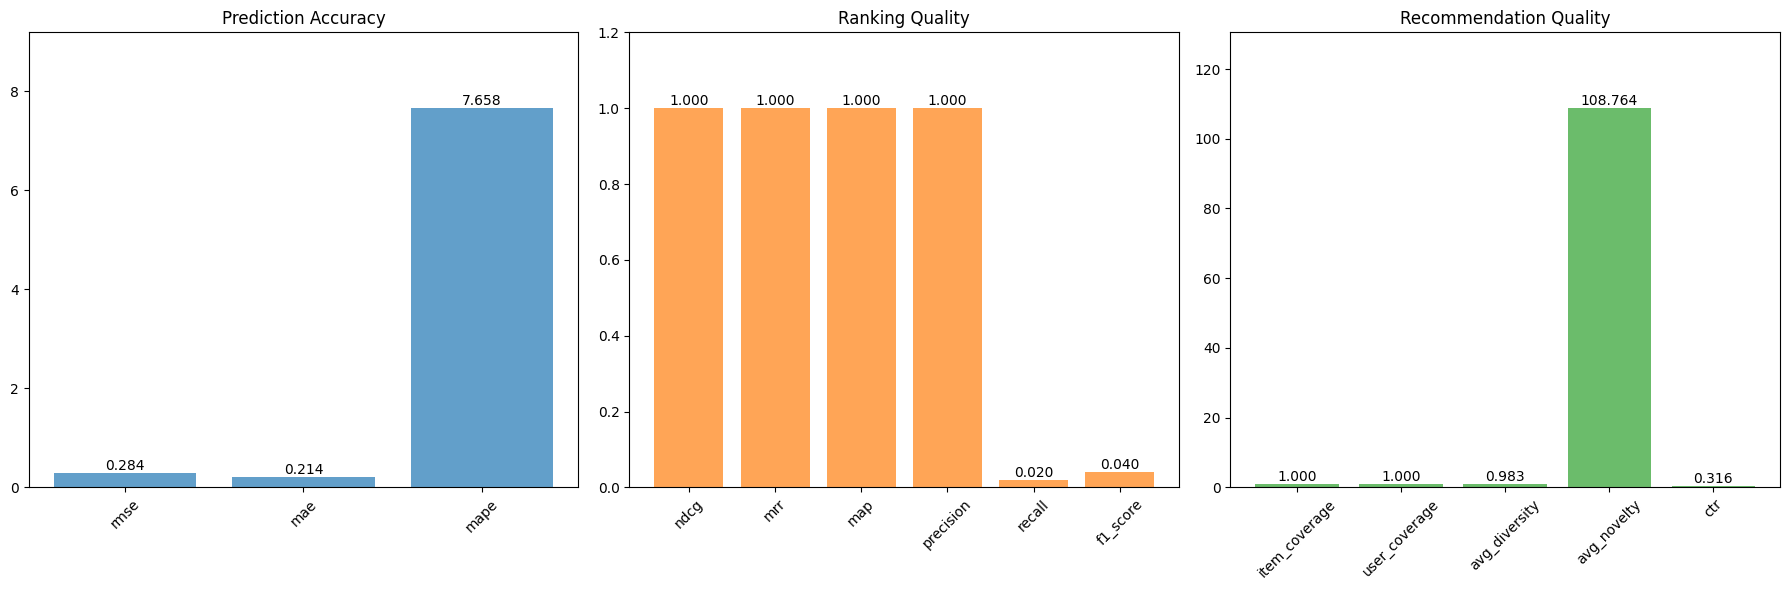

In [19]:
# Create visualization
print("📊 Creating evaluation visualization...")
fig = create_evaluation_visualization(comprehensive_results)

## Step 9: Interpretation and insights

In [20]:
def interpret_results(results):
    """Provide intelligent interpretation of evaluation results"""
    
    print("🔍 EVALUATION INSIGHTS:")
    print("-" * 30)
    
    # Extract key metrics
    rmse = results.get('pred_rmse', 0)
    ndcg = results.get('rank_ndcg', 0)
    precision = results.get('rank_precision', 0)
    coverage = results.get('rec_item_coverage', 0)
    diversity = results.get('rec_avg_diversity', 0)
    ctr = results.get('rec_ctr', 0)
    
    # Prediction accuracy interpretation
    print("📏 Prediction Accuracy:")
    if rmse < 0.5:
        print("   ✅ Excellent prediction accuracy")
    elif rmse < 1.0:
        print("   ✅ Good prediction accuracy")
    else:
        print("   ⚠️  Prediction accuracy could be improved")
    print(f"   RMSE: {rmse:.3f} (lower is better)")
    
    # Ranking quality interpretation
    print("\n🏆 Ranking Quality:")
    if ndcg > 0.8:
        print("   ✅ Excellent ranking quality")
    elif ndcg > 0.6:
        print("   ✅ Good ranking quality")
    else:
        print("   ⚠️  Ranking quality needs improvement")
    print(f"   NDCG: {ndcg:.3f} (higher is better)")
    
    # Precision interpretation
    print(f"\n🎯 Recommendation Relevance:")
    if precision > 0.7:
        print("   ✅ High precision - most recommendations are relevant")
    elif precision > 0.5:
        print("   ✅ Decent precision - recommendations are mostly relevant")
    else:
        print("   ⚠️  Low precision - many irrelevant recommendations")
    print(f"   Precision@k: {precision:.3f}")
    
    # Coverage interpretation
    print(f"\n📚 Catalog Coverage:")
    if coverage > 0.8:
        print("   ✅ Excellent coverage - using most of catalog")
    elif coverage > 0.5:
        print("   ✅ Good coverage - decent catalog utilization")
    else:
        print("   ⚠️  Low coverage - missing long-tail opportunities")
    print(f"   Item Coverage: {coverage:.3f}")
    
    # Business metrics interpretation
    if ctr > 0:
        print(f"\n💼 Business Impact:")
        if ctr > 0.1:
            print("   ✅ Strong user engagement")
        elif ctr > 0.05:
            print("   ✅ Moderate user engagement")
        else:
            print("   ⚠️  Low user engagement")
        print(f"   Click-through Rate: {ctr:.3f}")
    
    # Overall assessment
    print(f"\n🎯 OVERALL ASSESSMENT:")
    score = (ndcg + precision + coverage) / 3
    if score > 0.7:
        print("   🌟 Strong recommender system with good balance")
    elif score > 0.5:
        print("   ✅ Solid recommender system with room for improvement")
    else:
        print("   ⚠️  Recommender system needs significant improvements")
    
    print(f"\n💡 RECOMMENDATIONS FOR IMPROVEMENT:")
    if rmse > 1.0:
        print("   • Focus on improving prediction accuracy (better models, more features)")
    if ndcg < 0.6:
        print("   • Improve ranking quality (better scoring functions)")
    if precision < 0.5:
        print("   • Filter recommendations better (higher thresholds)")
    if coverage < 0.5:
        print("   • Increase diversity to cover more catalog")
    if ctr > 0 and ctr < 0.05:
        print("   • Improve user engagement (better personalization)")

In [21]:
# Run interpretation
interpret_results(comprehensive_results)

🔍 EVALUATION INSIGHTS:
------------------------------
📏 Prediction Accuracy:
   ✅ Excellent prediction accuracy
   RMSE: 0.284 (lower is better)

🏆 Ranking Quality:
   ✅ Excellent ranking quality
   NDCG: 1.000 (higher is better)

🎯 Recommendation Relevance:
   ✅ High precision - most recommendations are relevant
   Precision@k: 1.000

📚 Catalog Coverage:
   ✅ Excellent coverage - using most of catalog
   Item Coverage: 1.000

💼 Business Impact:
   ✅ Strong user engagement
   Click-through Rate: 0.316

🎯 OVERALL ASSESSMENT:
   🌟 Strong recommender system with good balance

💡 RECOMMENDATIONS FOR IMPROVEMENT:


## Step 10: Lessons Learned And Best Practices

🧠 KEY INSIGHTS FROM BUILDING THIS EVALUATION FRAMEWORK:

1. 🏗️  ARCHITECTURE DECISIONS:
   - ✅ Modular design makes code maintainable and testable
   - ✅ Configuration class provides flexibility without complexity
   - ✅ Separate metric families allow independent development
   - ✅ Comprehensive evaluator provides simple interface

2. 📊 METRIC SELECTION STRATEGY:
   - ✅ No single metric tells the complete story
   - ✅ Different stakeholders care about different metrics:
      • Engineers: RMSE, NDCG, Precision
      • Product: CTR, Conversion, Coverage  
      • Business: Revenue, Retention, Growth
   - ✅ Trade-offs are everywhere (accuracy vs diversity vs novelty)

3. 🔄 EVALUATION WORKFLOW:
   - ✅ Start with individual metric families during development
   - ✅ Use comprehensive evaluation for model comparison
   - ✅ Always interpret results in business context
   - ✅ Visualize results to communicate with stakeholders

4. ⚠️  COMMON PITFALLS TO AVOID:
   - ❌ Optimizing for just one metric (accuracy tunnel vision)
   - ❌ Ignoring business context when selecting metrics
   - ❌ Not considering user segments separately
   - ❌ Forgetting about computational costs in production

5. 🚀 PRODUCTION CONSIDERATIONS:
   - ✅ This framework works for offline evaluation
   - ✅ Online evaluation needs A/B testing (Part 2!)
   - ✅ Monitor metrics continuously in production
   - ✅ Be prepared for metric degradation over time

🎯 WHAT WE'VE BUILT:
- A flexible, extensible evaluation framework
- Clear separation of concerns between metric types
- Comprehensive coverage of evaluation dimensions
- Tools for interpretation and insight generation
- Foundation for production evaluation systems

🔮 WHAT'S NEXT:
In Part 2, we'll cover:
- Online evaluation and A/B testing
- Long-term impact measurement
- Fairness and bias evaluation
- Production monitoring strategies

🎉 CONGRATULATIONS!

You've successfully built a comprehensive recommender system evaluation framework!

This chain of thoughts approach showed you:
- ✅ WHY each design decision was made
- ✅ HOW different metrics complement each other  
- ✅ WHEN to use which evaluation approach
- ✅ WHERE the trade-offs and challenges lie

Your evaluation framework can now handle:
- 📊 Multi-dimensional evaluation (accuracy, ranking, diversity, business)
- 🔧 Flexible configuration for different use cases
- 📈 Comprehensive result interpretation and visualization
- 🎯 Real-world complexity and edge cases

Use this framework to evaluate your own recommender systems and make  data-driven decisions about improvements!

## Bonus : Quick Reference Guide

🎯 WHEN TO USE WHICH METRICS:

📊 ACCURACY METRICS (RMSE, MAE):
   * When: Rating prediction is core to your system
   * Good for: Model development and comparison
   * Watch out: High accuracy ≠ good recommendations

🏆 RANKING METRICS (NDCG, MAP, MRR):
   * When: You show ranked lists to users
   * Good for: Top-N recommendation scenarios
   * Watch out: Position matters more than exact scores

✅ CLASSIFICATION METRICS (Precision, Recall):
   * When: You think in terms of relevant/irrelevant
   * Good for: Understanding recommendation quality
   * Watch out: Threshold selection affects results significantly

🌈 DIVERSITY METRICS (Coverage, Novelty):
   * When: User discovery and long-term satisfaction matter
   * Good for: Fighting filter bubbles and echo chambers
   * Watch out: Often trades off with accuracy

💼 BUSINESS METRICS (CTR, Conversion):
   * When: You need to prove business value
   * Good for: Connecting technical performance to business impact
   * Watch out: Requires production data and A/B testing

🔧 QUICK USAGE EXAMPLES:

# Basic accuracy evaluation
```python
evaluator = RecommenderEvaluator()
accuracy = evaluator.evaluate_predictions(true_ratings, predictions)
```

# Ranking evaluation
```python
rankings = evaluator.evaluate_rankings(relevance_scores, prediction_scores)
```

# Full evaluation
```python
results = evaluator.comprehensive_evaluate(
    true_ratings, predictions, recommendations, 
    item_features, popularity, total_items, interactions
)
```